In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `c:\Users\mikul\Desktop\Persistence of Shocks\tvPersistence.jl - Cleaned\inflation_results_replication`


In [2]:
using BSON

## Inflation Pockets of Predictability Replication

In [3]:
tt=610     

test1 = BSON.load("results_Inflation_$tt-1.bson")
test2 = BSON.load("results_Inflation_$tt-2.bson")
test6 = BSON.load("results_Inflation_$tt-6.bson")
test12 = BSON.load("results_Inflation_$tt-12.bson")

# res=[Error_RW Error_AR2 Error_AR7 Error_EWD Error_AR2tv Error_EWDtv]

res1=test1["errors"];
res2=test2["errors"];
res6=test6["errors"];
res12=test12["errors"];

# forecasts=[RV_h horizon_forecast_RW horizon_forecast_AR2 horizon_forecast_AR7 horizon_forecast_EWD horizon_forecast_AR2tv horizon_forecast_EWDtv]

forecasts1=test1["forecasts"];
forecasts2=test2["forecasts"];
forecasts6=test6["forecasts"];
forecasts12=test12["forecasts"];

In [4]:
function tvOLS2(x, y, bw, tkernel; singular_ok::Bool = true)
    obs = size(x, 1)
    if length(y) != obs
        error("Dimensions of 'x' and 'y' are not compatible.")
    end

    nvar = size(x, 2)  # number of regressors
    
    theta     = zeros(obs, nvar)
    fitted    = zeros(obs)
    residuals = zeros(obs)
    
    grid = collect(1:obs) ./ obs

    for t in 1:obs
        tau0 = grid .- grid[t]
        kernel_weights = kernel0(tau0, bw, tkernel)
        kernel_weights /= sum(kernel_weights)
        k_idx = findall(kernel_weights .> 0)

        x_temp = x[k_idx, :]
        y_temp = y[k_idx]
        w_temp = kernel_weights[k_idx]

        XW = x_temp .* sqrt.(w_temp)
        yW = y_temp .* sqrt.(w_temp)

        try
            coef = (XW' * XW) \ (XW' * yW)
            theta[t, :] .= coef'
            fitted[t]    = dot(x[t, :], coef)
            residuals[t] = y[t] - fitted[t]

        catch e
            if e isa LinearAlgebra.SingularException
                if singular_ok
                    theta[t, :] .= NaN
                    fitted[t]    = NaN
                    residuals[t] = NaN
                else
                    rethrow(e)
                end
            else
                rethrow(e)
            end
        end
    end

    return (coefficients = theta, fitted = fitted, residuals = residuals)
end




function kernel0(t, bw, tkernel)
    z = t / bw
    if tkernel == "Gaussian"
        return exp.(-0.5 * z.^2) / sqrt(2 * pi)
    elseif tkernel == "Epa" || tkernel == "Epanechnikov"
        return max.(0, 0.75 * (1 .- z.^2))
    elseif tkernel == "onesided"
        return (z.>0).*exp.(-0.5 * z.^2)
    else
        error("Unknown kernel type")
    end
end
function SED_smooth_one(s1,s2,band)
    data=s1.^2 .- s2.^2;
    t=[t for t in 1.0:1.0:length(data)]
    result1 = tvOLS2(t, data, band,"onesided")
    return result1.fitted
end
function plot_pockets_spur_one(err1,err2,bw,bootthr,tit)

    mycolors_pockets=[mycolor[1] mycolor[1] mycolor[3]];
    
    plot(SED_smooth_one(err1,err2,bw),color=:white,ylim=[-0.1,0.2],legend=false,
    framestyle = :box,size=(1000,200),title = tit,
    xticks=(positions,["2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022"])) 
    plot!([[i,j] for (i,j) in find_intervals(SED_smooth_one(err1,err2,bw).>0.0)] ,fill=mycolor[4], fillalpha=0.2,linecolor=:transparent,seriestype=:vspan,label=false)
    plot!([[i,j] for (i,j) in find_intervals(SED_smooth_one(err1,err2,bw).>bootthr)] ,fill=mycolor[3], fillalpha=0.3,linecolor=:transparent,seriestype=:vspan,label=false)
    plot!(SED_smooth_one(err1,err2,bw),color=mycolor[1])
    plot!([0], seriestype="hline",linestyle=:dash,color=mycolor[3])
    plot!(fontfamily="serif-roman",titlefontsize=10, xtickfontsize=10,ytickfontsize=10,ylabelfontsize=10)
end

plot_pockets_spur_one (generic function with 1 method)

### New code

In [5]:
include("../src/SED_Thresholds/SEDThresholds.jl")
using .SEDThresholds

In [8]:
bootthr=[[0.007869 0.0143695 8.35799e-5 0.0039086]
    [0.0200952 0.0249548 0.00395962 0.00647051]
    [0.0568072 0.0613952 0.00968861 0.0137622]
    [0.0934724 0.086612 0.0123735 0.0179216]];

In [9]:
using Dates
# Define the start and end dates
start_date = Date(2011, 6, 1)
end_date = Date(2022, 9, 1)

# Generate monthly dates
monthly_dates = collect(start_date:Month(1):end_date)
beginning_of_year_dates = filter(d -> month(d) == 1, monthly_dates)
positions = findall(d -> month(d) == 1, monthly_dates);
labels = string.(year.(beginning_of_year_dates))

11-element Vector{String}:
 "2012"
 "2013"
 "2014"
 "2015"
 "2016"
 "2017"
 "2018"
 "2019"
 "2020"
 "2021"
 "2022"

### Srovnání s Revision_Inflation_POCKETS_BW.ipynb
- SEDThresholds.SED_smooth_one() z mého modulu má otočené znaménko u one-sided kernelu (viz soubor src/TvPersistence/src/tv_ols.jl funkce kernel()). Pro ostatní kernely se SED curve replikuje správně
- tvLM() používá intercept v regresi, SED_smooth_one() ho nepoužívá, ale v paperu je specifikovaná regrese s interceptem -> další zdroj rozdílu
- Srovnání s funkcí plot_pockets_spur(), která používá R funkci tvLM() vypadá stejně (zde je použit triweight kernel)

In [10]:
bw = 0.03
mycolor=[colorant"rgb(222,102,62)",colorant"rgb(255,145,43)",colorant"rgb(76,144,186)",colorant"rgb(43,194,194)",colorant"rgb(244,184,17)"]

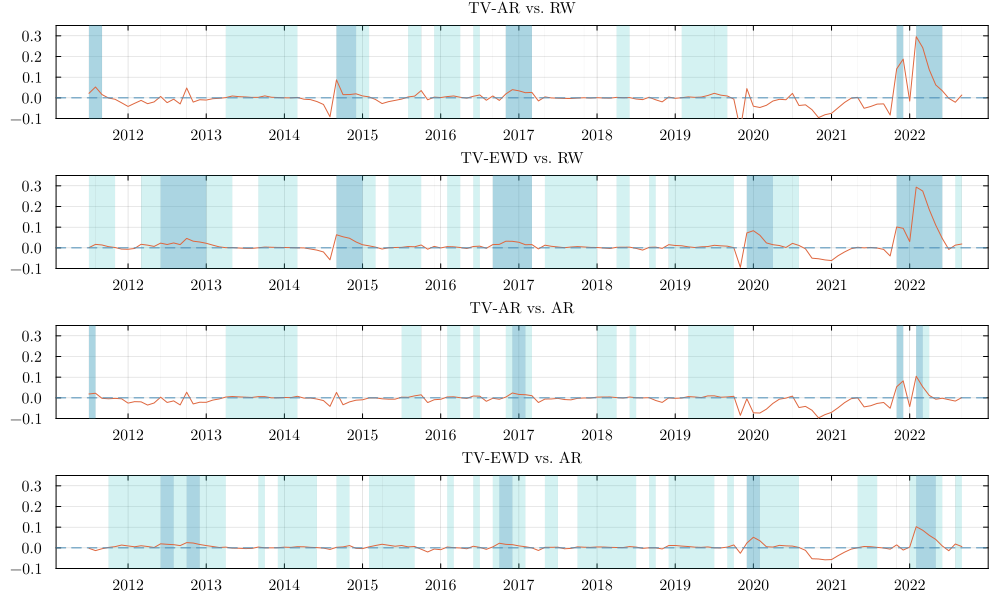

In [11]:
p1 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p2 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p3 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p4 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[3]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[1],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

pockets_plot = plot(p1,p2,p3,p4,layout = (4,1), legend = false, size = (1000, 600))
plot!(pockets_plot, fontfamily="serif-roman",xtickfontsize=10,ytickfontsize=10, ylim = (-0.1, 0.35))

In [16]:
savefig(pockets_plot, "../readme_files/pockets_plot_inflation.pdf")

"c:\\Users\\mikul\\Desktop\\Persistence of Shocks\\tvPersistence.jl - Cleaned\\readme_files\\pockets_plot_inflation.pdf"

In [13]:
mycolor=palette(:Greys_8)

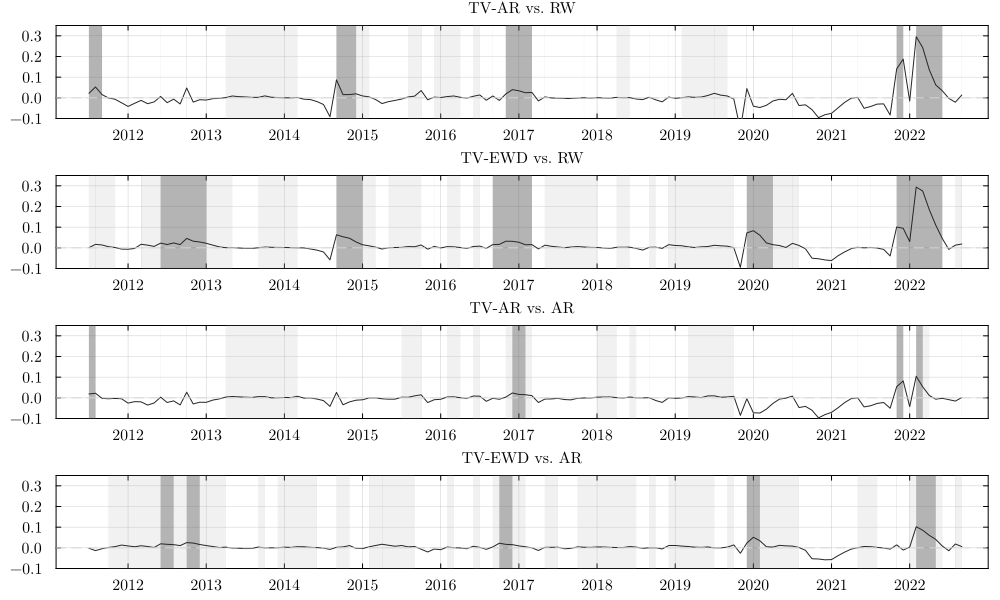

In [14]:
p1 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p2 = SEDThresholds.plot_pockets(
    res1[][:,1],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. RW",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p3 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,5],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-AR vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

p4 = SEDThresholds.plot_pockets(
    res1[][:,2],
    res1[][:,6],
    beginning_of_year_dates,
    bw,
    bootthr[1,2];
    include_intercept = true,
    kernel_type = "one-sided",
    plot_zero_pockets = true,
    title = "TV-EWD vs. AR",
    auto_xticks = false,
    user_xticks = (positions, labels),
    pocket_colors = [mycolor[4], mycolor[8]],
    pocket_alphas = [0.2, 0.3],
    sed_line_color = mycolor[8],
    hline_color = mycolor[3],
    hline_style = :dash,
    base_line_color = :white,
    plot_size = (1000,200),
    framestyle = :box,
    fontfamily = "serif-roman",
    title_fontsize = 10,
    xtick_fontsize = 10,
    ytick_fontsize = 10,
    ylabel_fontsize = 10
)

plot!(p1, ylim=(-0.1, 0.2))

pockets_plot_bw = plot(p1,p2,p3,p4,layout = (4,1), legend = false, size = (1000, 600))
plot!(fontfamily="serif-roman",xtickfontsize=10,ytickfontsize=10, ylim=(-0.1, 0.35)) 

In [15]:
savefig(pockets_plot_bw, "../readme_files/pockets_plot_inflation_bw.pdf")

"c:\\Users\\mikul\\Desktop\\Persistence of Shocks\\tvPersistence.jl - Cleaned\\readme_files\\pockets_plot_inflation_bw.pdf"